# Sensitivity analysis

OFAT + Sobol with first/total order only, **parallelised across CPU cores via joblib**.

- 5 parameters: `rejection_cost`, `rationality`, `interaction_radius`, `interaction_std`, `n_agents`.
- Sobol with `calc_second_order=False`: `N × (D+2) × reps` runs.
  N=512, D=5, reps=10 → **35,840 runs**. With 8 cores this runs in ~1–1.5 hours instead of 8–10.
- Two outputs:
  - `couple_quality` — mean true compatibility of currently-matched pairs (singles excluded)
  - `blocking_frac` — blocking pairs / all opposite-gender pairs

**Prerequisites** (same folder): `dating_market.py`, `matching_metrics.py`.
**Install**: `pip install SALib joblib`.

In [ ]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

import warnings; warnings.filterwarnings("ignore", category=RuntimeWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing as mp
from joblib import Parallel, delayed

from matching_metrics import InstrumentedDatingMarket

# SALib (new API preferred, fall back to old)
try:
    from SALib.sample.sobol import sample as sobol_sample
except Exception:
    from SALib.sample import saltelli
    def sobol_sample(problem, N, calc_second_order=False):
        return saltelli.sample(problem, N, calc_second_order=calc_second_order)
from SALib.analyze import sobol as sobol_analyze

# --- toggles ---
QUICK = False
N_JOBS = -1            # -1 = use every CPU; set to a specific number to leave cores free

print(f"available cores: {mp.cpu_count()}   N_JOBS = {N_JOBS}")

problem = {
    "num_vars": 5,
    "names":   ["rejection_cost", "rationality", "interaction_radius", "interaction_std", "n_agents"],
    "bounds":  [[0.2, 3.0],       [0.5, 30.0],   [2, 10],              [0.1, 1.0],        [50, 200]],
}
INT_PARAMS = {"interaction_radius", "n_agents"}
BASELINE   = dict(rejection_cost=1.0, rationality=6.0, interaction_radius=5,
                  interaction_std=0.5, n_agents=120)

# fixed (not in SA)
THRESH, GBAL, REL_LEN, MEMORY = 0.6, 0.5, 10, 8

if QUICK:
    N_GRID, N_STEPS, BURN_IN = 40, 200, 80
    OFAT_DISTINCT, OFAT_REPS = 5, 3
    N_SALTELLI, SOBOL_REPS   = 64, 1
else:
    N_GRID, N_STEPS, BURN_IN = 40, 200, 80
    OFAT_DISTINCT, OFAT_REPS = 10, 20
    N_SALTELLI, SOBOL_REPS   = 512, 10                 # -> 512 * 7 * 10 = 35,840 runs

available cores: 10   N_JOBS = -1


In [2]:
def run_config(rejection_cost, rationality, interaction_radius, interaction_std, n_agents, seed,
               n_grid=None, n_steps=None, burn_in=None):
    """One homogeneous-population run.

    Pure function: no shared state, all randomness driven by `seed`. Safe to call from
    parallel workers in any order -- same (params, seed) always gives the same output.
    Defaults to module-level QUICK/full settings; can be overridden for OFAT etc.
    """
    n_grid  = N_GRID  if n_grid  is None else n_grid
    n_steps = N_STEPS if n_steps is None else n_steps
    burn_in = BURN_IN if burn_in is None else burn_in
    n_agents = int(round(n_agents))
    m = InstrumentedDatingMarket(n_grid=n_grid, interaction_std=float(interaction_std),
                                 interaction_radius=int(round(interaction_radius)),
                                 relationship_length=REL_LEN, seed=seed)
    m.add_agents(n_agents, gender_balance=GBAL, move_prob=0.5,
                 rejection_cost=float(rejection_cost), rationality=float(rationality),
                 relation_threshold=THRESH, memory_depth=MEMORY, label="pop")
    nmale = sum(a.is_male for a in m.subjects); npair = nmale * (n_agents - nmale)
    qs, bfs = [], []
    for t in range(n_steps):
        m.step()
        if t < burn_in:
            continue
        matched = [a for a in m.subjects if not a.is_single and a.partner is not None]
        if matched:
            qs.append(float(np.mean([m.compatibility(a.id, a.partner) for a in matched])))
        bfs.append(m.matching_metrics()["blocking_pairs"] / max(npair, 1))
    return dict(
        couple_quality=float(np.mean(qs)) if qs else float("nan"),
        blocking_frac=float(np.mean(bfs)) if bfs else float("nan"),
    )

## 1. OFAT

Vary one parameter while holding the others at `BASELINE`. Each `(parameter value, seed)` is
one task; joblib distributes the whole set across cores.

In [3]:
import time

def run_ofat():
    """Build the full task list and run in parallel."""
    tasks = []                   # each: (var_name, val, seed, args_dict)
    for i, var in enumerate(problem["names"]):
        samples = np.linspace(*problem["bounds"][i], num=OFAT_DISTINCT)
        if var in INT_PARAMS:
            samples = np.unique(np.round(samples).astype(int))
        for val in samples:
            args = dict(BASELINE); args[var] = val
            for s in range(OFAT_REPS):
                tasks.append((var, val, s, args))

    print(f"OFAT: {len(tasks)} runs across {N_JOBS} jobs")
    t0 = time.time()
    raw = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(run_config)(**args, seed=s) for (_, _, s, args) in tasks
    )
    print(f"OFAT done in {time.time()-t0:.0f}s")

    by_var = {var: [] for var, *_ in tasks}
    for (var, val, s, _), out in zip(tasks, raw):
        by_var[var].append({var: val, **out})
    return {var: pd.DataFrame(rows) for var, rows in by_var.items()}

ofat = run_ofat()

OFAT: 980 runs across -1 jobs


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 268 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   21.0s
[Parallel(n_jobs=-1)]: Done 628 tasks      | elapsed:   30.6s
[Parallel(n_jobs=-1)]: Done 862 tasks      | elapsed:   40.0s


OFAT done in 47s


[Parallel(n_jobs=-1)]: Done 980 out of 980 | elapsed:   47.3s finished


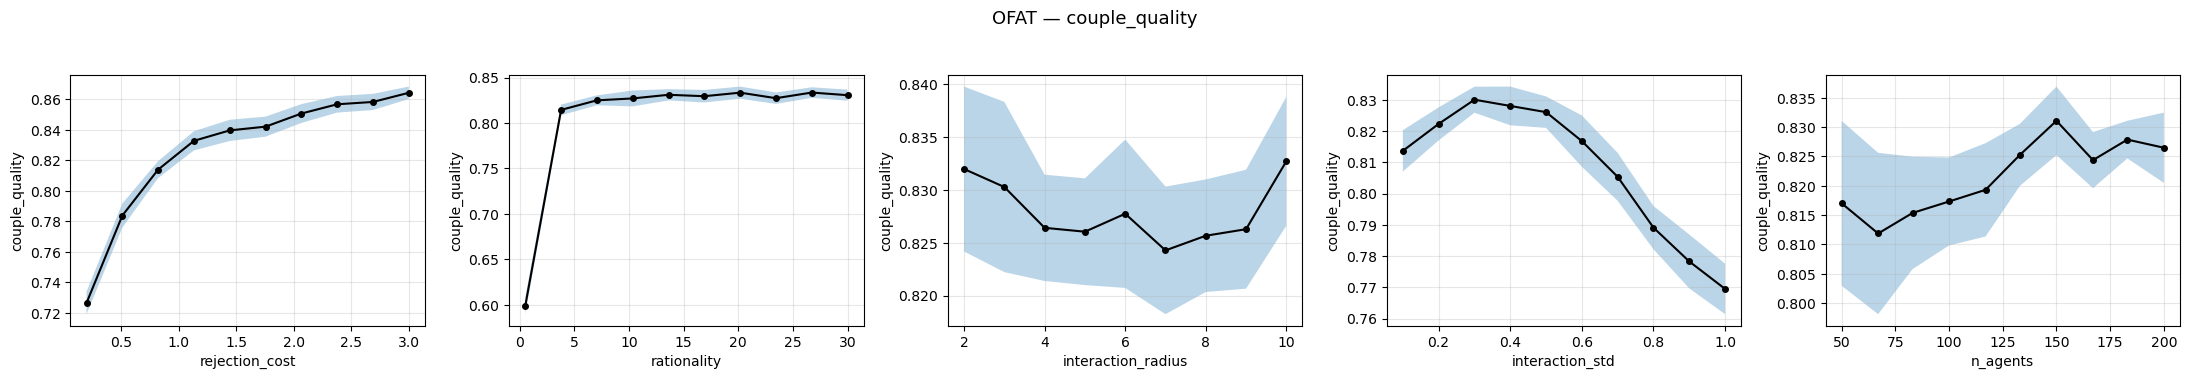

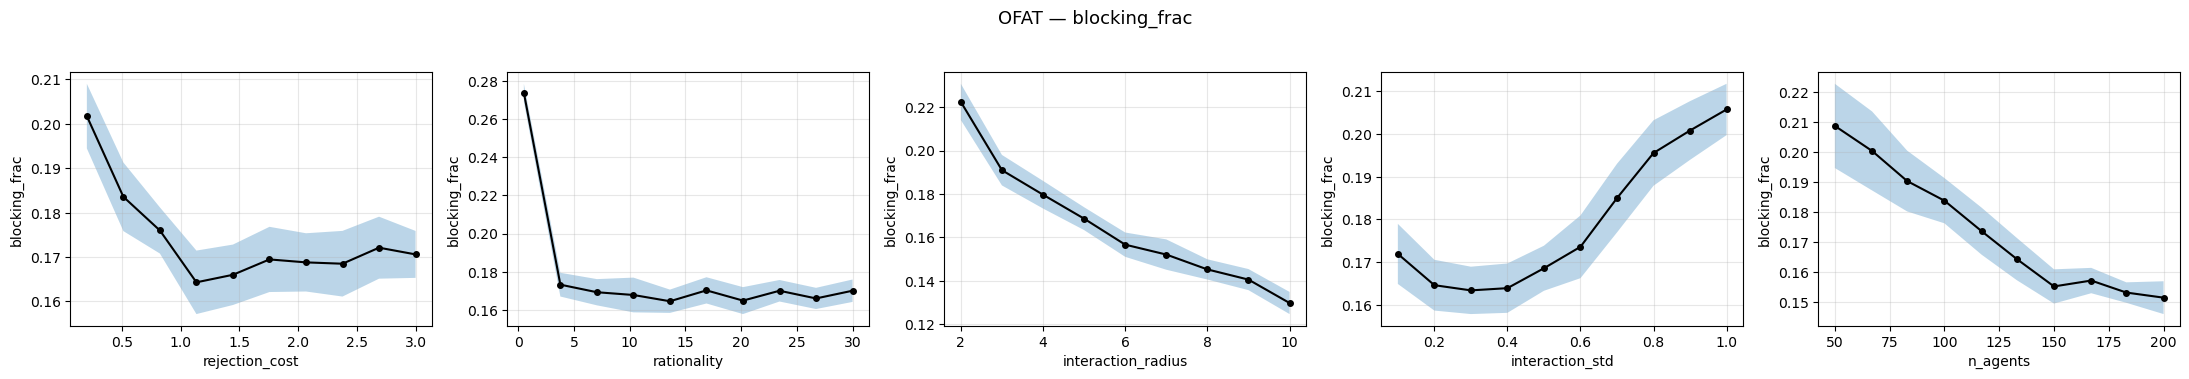

In [4]:
def plot_ofat(metric):
    fig, axs = plt.subplots(1, 5, figsize=(22, 3.6))
    for ax, var in zip(axs, problem["names"]):
        df = ofat[var]; g = df.groupby(var)[metric]
        x = g.mean().index.values; y = g.mean().values
        err = 1.96 * g.std().values / np.sqrt(g.count().values)
        ax.plot(x, y, "-o", c="k", ms=4)
        ax.fill_between(x, y - err, y + err, alpha=.3)
        ax.set_xlabel(var); ax.set_ylabel(metric); ax.grid(alpha=.3)
    fig.suptitle(f"OFAT — {metric}", y=1.04, fontsize=13)
    plt.tight_layout(); plt.show()

for metric in ("couple_quality", "blocking_frac"):
    plot_ofat(metric)

## 2. Sobol

`calc_second_order=False`. Every `(sample_point_index, seed)` pair is one independent task —
maximum parallelism. Tasks are dispatched across all available cores; replicates within a
sample point are then averaged on the master after all tasks complete.

With N_SALTELLI=512, D=5, reps=10: `N × (D+2) = 512 × 7 = 3,584` sample points, × 10 reps = 35,840

In [5]:
X = sobol_sample(problem, N_SALTELLI, calc_second_order=False)
total = X.shape[0] * SOBOL_REPS
print(f"{X.shape[0]} sample points x {SOBOL_REPS} reps = {total} parallel tasks")

# build the flat task list: (sample_point_index, seed) for every combination
tasks = [(i, s) for i in range(X.shape[0]) for s in range(SOBOL_REPS)]

t0 = time.time()
results = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(run_config)(*X[i], seed=s) for (i, s) in tasks
)
print(f"all runs done in {(time.time()-t0)/60:.1f} min")

3584 sample points x 10 reps = 35840 parallel tasks


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 268 tasks      | elapsed:   15.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   24.6s
[Parallel(n_jobs=-1)]: Done 628 tasks      | elapsed:   34.5s
[Parallel(n_jobs=-1)]: Done 862 tasks      | elapsed:   51.9s
[Parallel(n_jobs=-1)]: Done 1132 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1438 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 2158 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 2572 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 3022 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done 3508 tasks      | elapsed:  4.5min
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed:  5.3min
[Parallel(n_jobs=-1)]: Done 4588 tasks      | e

all runs done in 53.7 min


[Parallel(n_jobs=-1)]: Done 35840 out of 35840 | elapsed: 53.7min finished


In [6]:
# average replicates back into one Y per sample point
by_point = {}
for (i, _), out in zip(tasks, results):
    by_point.setdefault(i, []).append(out)

records = []
for i in range(X.shape[0]):
    reps = by_point[i]
    point = {n: X[i, j] for j, n in enumerate(problem["names"])}
    for metric in ("couple_quality", "blocking_frac"):
        vals = [r[metric] for r in reps if not np.isnan(r[metric])]
        point[metric] = float(np.mean(vals)) if vals else float("nan")
    records.append(point)

sobol_df = pd.DataFrame(records)
sobol_df.to_csv("sobol_5param_parallel_results.csv", index=False)
print(f"Saved sobol_5param_parallel_results.csv ({len(sobol_df)} rows)")
sobol_df.head()

Saved sobol_5param_parallel_results.csv (3584 rows)


,rejection_cost,rationality,interaction_radius,interaction_std,n_agents,couple_quality,blocking_frac
0,1.103043,5.995390,4.344076,0.242052,159.82098,0.834161,0.159307
1,1.062660,5.995390,4.344076,0.242052,159.82098,0.829543,0.162635
2,1.103043,9.414838,4.344076,0.242052,159.82098,0.839775,0.153454
3,1.103043,5.995390,6.855977,0.242052,159.82098,0.836383,0.137115
4,1.103043,5.995390,4.344076,0.992041,159.82098,0.775684,0.207453


In [ ]:
# sobol_df = pd.read_csv("sobol_5param_parallel_results.csv")

Si = {}
for metric in ("couple_quality", "blocking_frac"):
    y = sobol_df[metric].values
    mask = ~np.isnan(y)
    if mask.sum() < len(y):
        print(f"  {metric}: dropped {(~mask).sum()} NaN rows")
        y = y[mask]
    Si[metric] = sobol_analyze.analyze(problem, y, calc_second_order=False, print_to_console=False)
    print(f"=== {metric} ===")
    print(f"  {'parameter':>22}    S1 (95% CI)        ST (95% CI)")
    for nm, s1, s1c, st, stc in zip(problem["names"],
                                     Si[metric]["S1"], Si[metric]["S1_conf"],
                                     Si[metric]["ST"], Si[metric]["ST_conf"]):
        print(f"  {nm:>22}  {s1:6.3f} +/- {s1c:5.3f}   {st:6.3f} +/- {stc:5.3f}")
    print()

=== couple_quality ===
               parameter    S1 (95% CI)        ST (95% CI)
          rejection_cost   0.403 +/- 0.115    0.504 +/- 0.102
             rationality   0.349 +/- 0.139    0.413 +/- 0.094
      interaction_radius  -0.005 +/- 0.014    0.015 +/- 0.003
         interaction_std   0.190 +/- 0.067    0.219 +/- 0.041
                n_agents   0.023 +/- 0.022    0.026 +/- 0.005

=== blocking_frac ===
               parameter    S1 (95% CI)        ST (95% CI)
          rejection_cost   0.024 +/- 0.026    0.061 +/- 0.011
             rationality   0.070 +/- 0.057    0.090 +/- 0.032
      interaction_radius   0.473 +/- 0.086    0.519 +/- 0.081
         interaction_std   0.192 +/- 0.061    0.234 +/- 0.035
                n_agents   0.180 +/- 0.053    0.205 +/- 0.031



## 3. How much does each parameter account for?

- **Pie**: variance share from each parameter's main effect (clipped S1), remainder labelled "interactions".
- **S1 vs ST**: main effect vs total effect; ST ≫ S1 means the parameter mostly acts via interactions.
- **Tornado**: parameters ranked by ST — the headline.

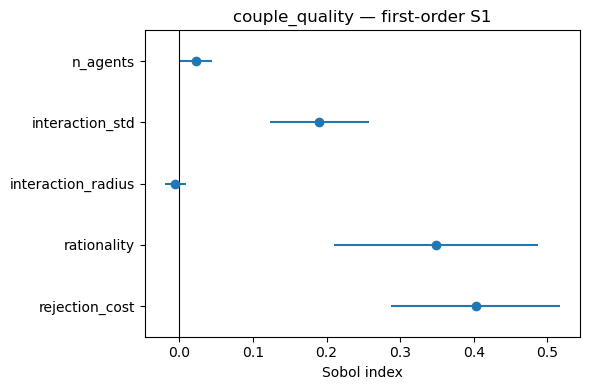

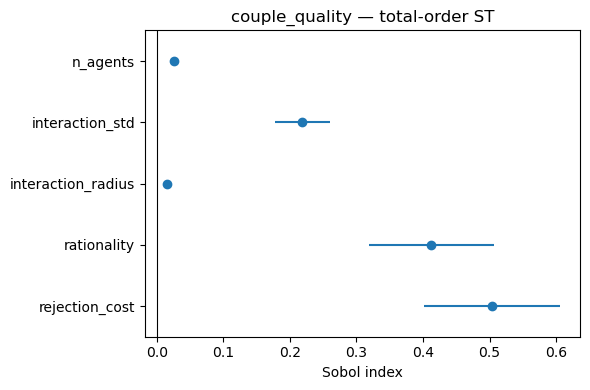

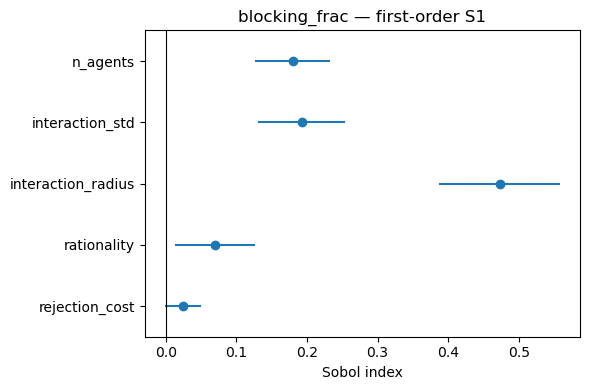

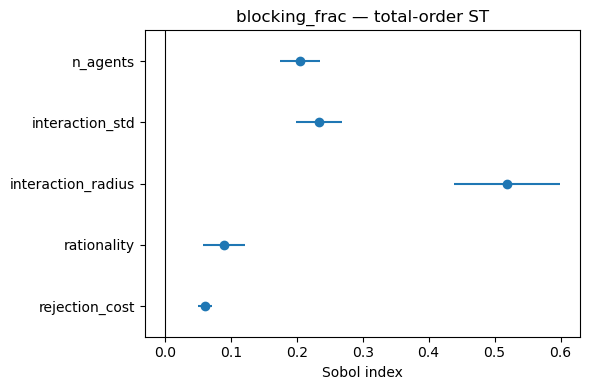

In [8]:
def plot_index(s, params, order, title=""):
    names = params; idx = s["S" + order]; err = s["S" + order + "_conf"]
    l = len(idx)
    plt.figure(figsize=(6, 0.5 * l + 1.5))
    plt.title(title); plt.ylim([-0.5, l - 0.5])
    plt.yticks(range(l), names)
    plt.errorbar(idx, range(l), xerr=err, linestyle="None", marker="o")
    plt.axvline(0, c="k", lw=.8); plt.xlabel("Sobol index")
    plt.tight_layout(); plt.show()

for metric in ("couple_quality", "blocking_frac"):
    plot_index(Si[metric], problem["names"], "1", f"{metric} — first-order S1")
    plot_index(Si[metric], problem["names"], "T", f"{metric} — total-order ST")

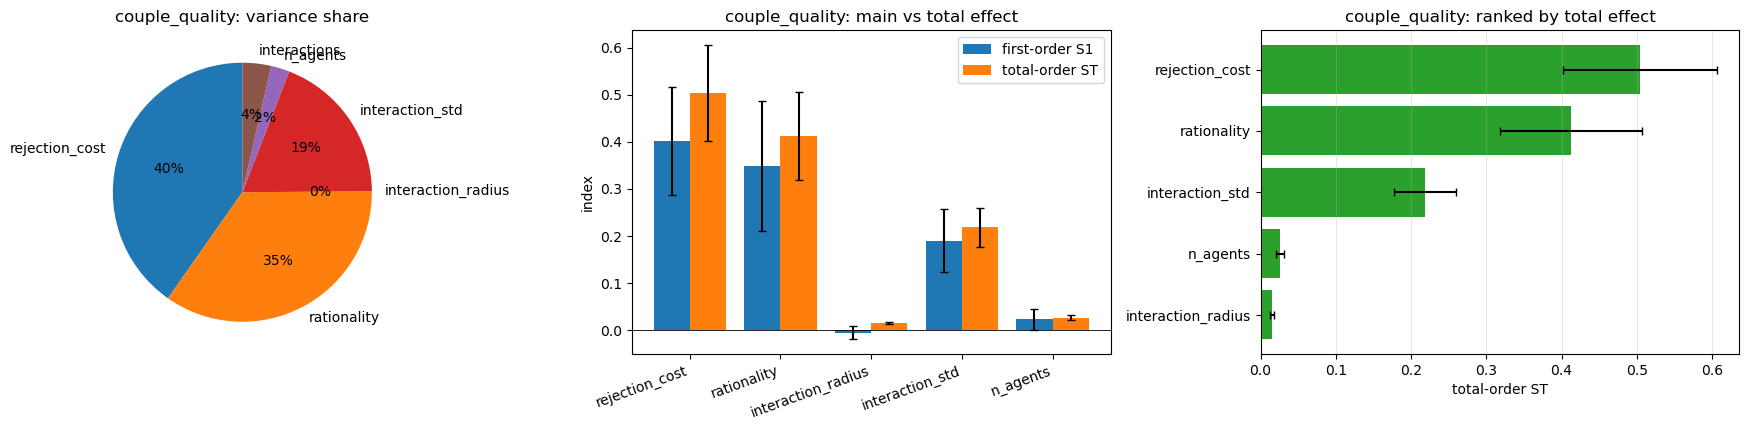

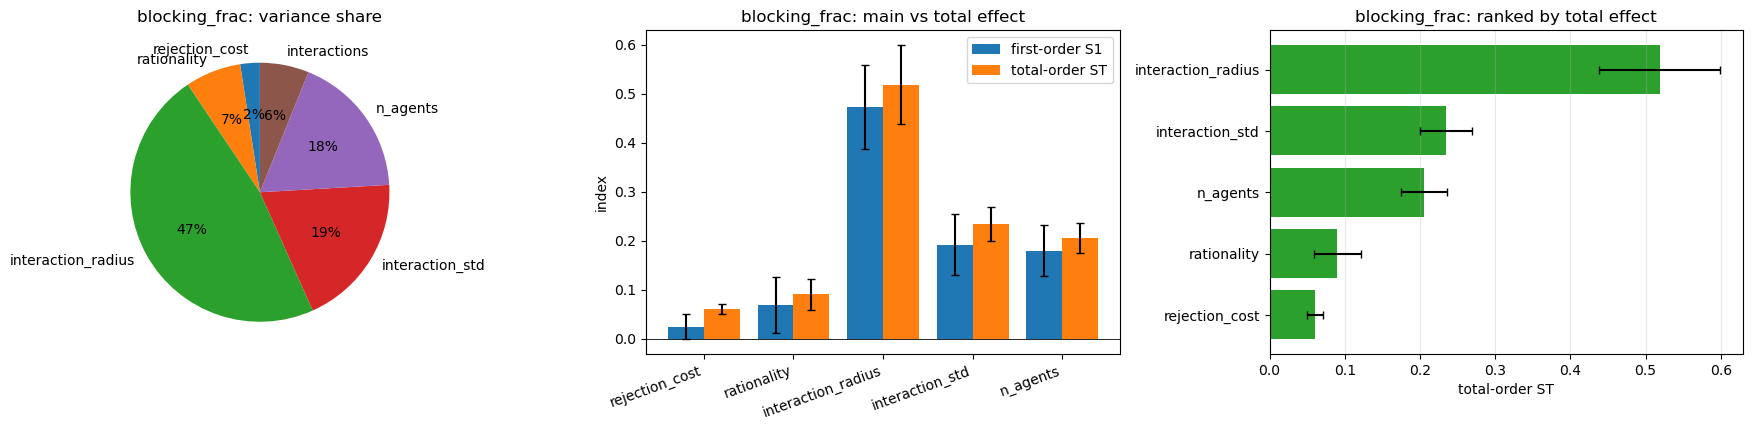

In [9]:
def variance_views(metric):
    s = Si[metric]; names = problem["names"]; D = len(names)
    s1 = np.clip(np.array(s["S1"]), 0, None)
    inter = max(0.0, 1 - s1.sum())

    fig = plt.figure(figsize=(18, 4.4))
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.pie(list(s1) + [inter], labels=names + ["interactions"],
            autopct="%1.0f%%", startangle=90,
            colors=plt.cm.tab10(np.arange(D + 1)))
    ax1.set_title(f"{metric}: variance share")

    ax2 = fig.add_subplot(1, 3, 2)
    x = np.arange(D)
    ax2.bar(x - 0.2, s["S1"], 0.4, yerr=s["S1_conf"], capsize=3, label="first-order S1")
    ax2.bar(x + 0.2, s["ST"], 0.4, yerr=s["ST_conf"], capsize=3, label="total-order ST")
    ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=20, ha="right")
    ax2.axhline(0, c="k", lw=.6); ax2.set_ylabel("index"); ax2.legend()
    ax2.set_title(f"{metric}: main vs total effect")

    ax3 = fig.add_subplot(1, 3, 3)
    order = np.argsort(s["ST"]); pos = np.arange(D)
    ax3.barh(pos, np.array(s["ST"])[order],
             xerr=np.array(s["ST_conf"])[order], capsize=3, color="C2")
    ax3.set_yticks(pos); ax3.set_yticklabels([names[i] for i in order])
    ax3.set_xlabel("total-order ST"); ax3.set_title(f"{metric}: ranked by total effect")
    ax3.grid(axis="x", alpha=.3)
    plt.tight_layout(); plt.show()

for metric in ("couple_quality", "blocking_frac"):
    variance_views(metric)